In [4]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('Intel_CPUs_Cleaned_Final.csv')

# Lọc 2 nhóm Launched và End of Life
launched = data[data['Status'] == 'Launched']['Recommended_Customer_Price']
eol = data[data['Status'] == 'End of Life']['Recommended_Customer_Price']

print(f"Launched: n={len(launched)}, mean={launched.mean():.2f}, sd={launched.std(ddof=1):.2f}")
print(f"End of Life: n={len(eol)}, mean={eol.mean():.2f}, sd={eol.std(ddof=1):.2f}")

Launched: n=1043, mean=864.14, sd=1524.98
End of Life: n=434, mean=580.51, sd=790.68


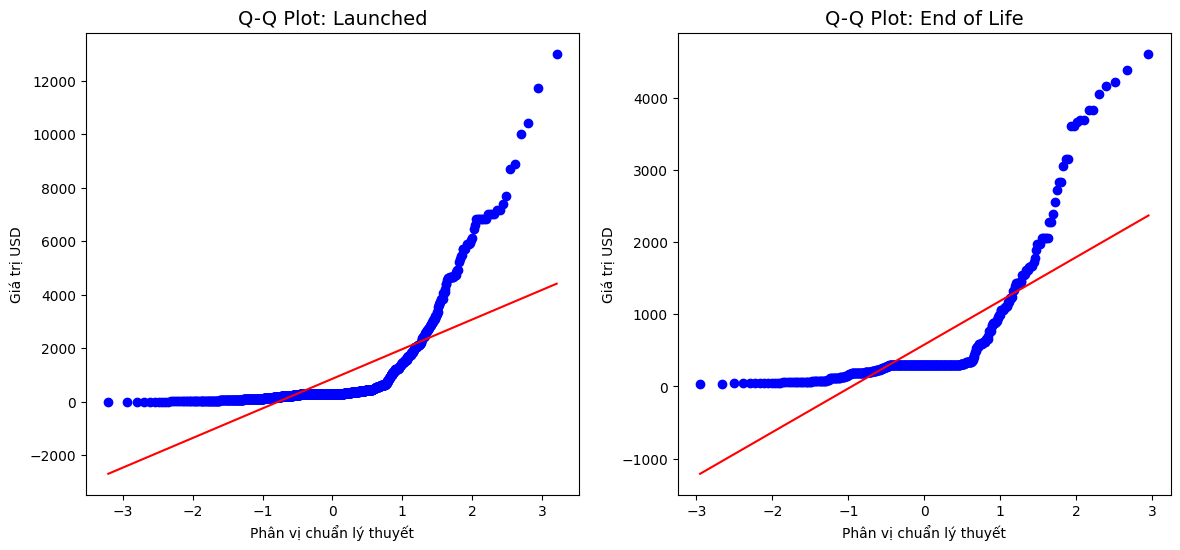

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vẽ Q-Q Plot cho nhóm Launched (Đồ thị bên trái)
stats.probplot(launched, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Launched", fontsize=14)
axes[0].set_ylabel("Giá trị USD")
axes[0].set_xlabel("Phân vị chuẩn lý thuyết")

# Vẽ Q-Q Plot cho nhóm End of Life (Đồ thị bên phải)
stats.probplot(eol, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: End of Life", fontsize=14)
axes[1].set_ylabel("Giá trị USD")
axes[1].set_xlabel("Phân vị chuẩn lý thuyết")

plt.show()

In [9]:
stat_l, p_value_l = stats.shapiro(launched)
stat_e, p_value_e = stats.shapiro(eol)

print(f"Launched: stat = {stat_l:.4f}, p-value = {p_value_l:.4e}")
print(f"EOL     : stat = {stat_e:.4f}, p-value = {p_value_e:.4e}")

Launched: stat = 0.5261, p-value = 2.7774e-46
EOL     : stat = 0.5866, p-value = 8.0454e-31


In [10]:
stat_lev, p_lev = stats.levene(launched, eol)

print(f"Levene: stat = {stat_l:.4f}, p-value = {p_value_l:.4e}")

Levene: stat = 0.5261, p-value = 2.7774e-46


In [ ]:
#Dùng greater để tính kiểm định 1 phía
t_stat, p_val = stats.ttest_ind(launched, eol, equal_var=False, alternative='greater')

print(f"Giá trị kiểm định t: {t_stat:.4f} , p-value = {p_val}")

Giá trị kiểm định t: 4.6818 , p-value = 1.5591966952946572e-06


: 